# Roteiro de Laboratório — Governança em ITIL com Python

**Curso:** Sistemas de Informação  
**Disciplina:** Gestão de Sistemas de Informação  
**Tema:** Governança de TI – ITIL aplicado em Python  
**Empresa fictícia:** TechStore S.A.

**Integrantes:** Lucas & Luis

---

## Atividades
| # | Tema | Processo ITIL |
|---|------|---------------|
| 1 | Monitor de Disponibilidade de Serviços | Availability Management |
| 2 | Auditoria do Gerenciamento de Mudanças | Change Management |
| 3 | Gerenciamento de Incidentes com Fila | Incident Management |


## Importações e Configurações Globais

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random

# Estilo visual padronizado para todos os gráficos
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


---
## Atividade 1 — Gerenciamento de Disponibilidade (Availability Management)

### Fundamentação Teórica

O **Gerenciamento de Disponibilidade** garante que os serviços de TI estejam disponíveis
sempre que o negócio precisar, conforme acordado no SLA.

A disponibilidade é calculada pela fórmula:

$$
\text{Disponibilidade (\%)} = \frac{\text{Tempo Acordado} - \text{Tempo de Indisponibilidade}}{\text{Tempo Acordado}} \times 100
$$

**Cenário:** A TechStore S.A. opera **4 serviços críticos** com meta de **99,5%** de
disponibilidade mensal (mês de 30 dias = 43.200 minutos).


In [9]:
# ============================================================
# ATIVIDADE 1 — GERENCIAMENTO DE DISPONIBILIDADE (ITIL)
# ============================================================

# ── Constantes ───────────────────────────────────────────────
MINUTOS_NO_MES: int = 43200       # 30 dias × 24 h × 60 min
META_DISPONIBILIDADE: float = 99.5  # percentual mínimo exigido pelo SLA


def calcular_disponibilidade(minutos_indisponiveis: float,
                              minutos_acordados: int = MINUTOS_NO_MES) -> float:
    """Calcula a disponibilidade percentual de um serviço.

    Fórmula ITIL:
        Disponibilidade (%) = ((Acordado - Indisponível) / Acordado) × 100

    :param minutos_indisponiveis: Total de minutos em que o serviço ficou fora do ar.
    :param minutos_acordados: Total de minutos do período acordado no SLA.
    :return: Percentual de disponibilidade arredondado em 3 casas decimais.
    """
    return round(
        ((minutos_acordados - minutos_indisponiveis) / minutos_acordados) * 100,
        3
    )


def identificar_violacoes(df: pd.DataFrame,
                           coluna_disp: str,
                           meta: float) -> pd.DataFrame:
    """Filtra serviços que violaram a meta de disponibilidade do SLA.

    :param df: DataFrame com os dados de disponibilidade.
    :param coluna_disp: Nome da coluna que contém o percentual de disponibilidade.
    :param meta: Percentual mínimo exigido pelo SLA.
    :return: DataFrame contendo apenas os registros em não-conformidade.
    """
    return df[df[coluna_disp] < meta].copy()


# ── Dados dos serviços ───────────────────────────────────────
dados_disponibilidade = {
    "servico": [
        "ERP",
        "Portal do Cliente",
        "Sistema de Pagamentos",
        "E-mail Corporativo",
    ],
    "tempo_indisponivel_min": [80, 250, 15, 420],
}

df_disp = pd.DataFrame(dados_disponibilidade)

# ── Cálculos ─────────────────────────────────────────────────
df_disp["disponibilidade_pct"] = df_disp["tempo_indisponivel_min"].apply(
    calcular_disponibilidade
)
df_disp["status"] = df_disp["disponibilidade_pct"].apply(
    lambda d: "✅ OK" if d >= META_DISPONIBILIDADE else "❌ VIOLAÇÃO"
)

violacoes_disp = identificar_violacoes(df_disp, "disponibilidade_pct", META_DISPONIBILIDADE)

# ── Relatório de auditoria ───────────────────────────────────
LINHA = "=" * 60

print(f"{'RELATÓRIO DE DISPONIBILIDADE — TECHSTORE S.A.':^60}")
print(LINHA)
print(df_disp.to_string(index=False))
print()
print(LINHA)
print(f"  VIOLAÇÕES DE DISPONIBILIDADE  (Meta: {META_DISPONIBILIDADE}%)")
print(LINHA)

if violacoes_disp.empty:
    print("  ✅ Nenhuma violação detectada. Todos os serviços dentro da meta.")
else:
    print(violacoes_disp[["servico", "disponibilidade_pct", "status"]].to_string(index=False))
    print(f"\n  Total de serviços em não-conformidade: {len(violacoes_disp)}")


       RELATÓRIO DE DISPONIBILIDADE — TECHSTORE S.A.        
              servico  tempo_indisponivel_min  disponibilidade_pct     status
                  ERP                      80               99.815       ✅ OK
    Portal do Cliente                     250               99.421 ❌ VIOLAÇÃO
Sistema de Pagamentos                      15               99.965       ✅ OK
   E-mail Corporativo                     420               99.028 ❌ VIOLAÇÃO

  VIOLAÇÕES DE DISPONIBILIDADE  (Meta: 99.5%)
           servico  disponibilidade_pct     status
 Portal do Cliente               99.421 ❌ VIOLAÇÃO
E-mail Corporativo               99.028 ❌ VIOLAÇÃO

  Total de serviços em não-conformidade: 2


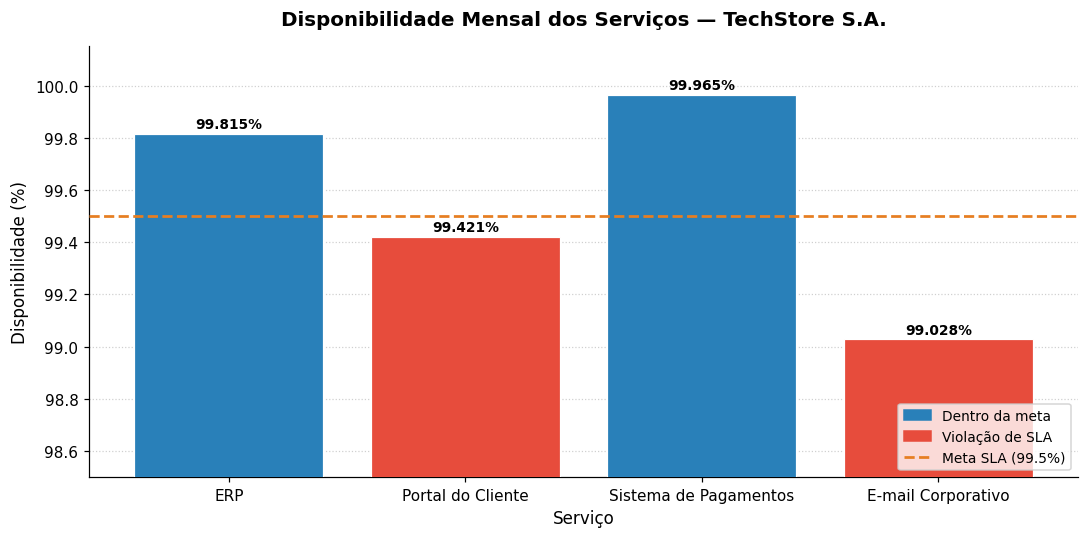

In [10]:
# ── Gráfico de barras — Disponibilidade por Serviço ─────────
cores = [
    "#e74c3c" if d < META_DISPONIBILIDADE else "#2980b9"
    for d in df_disp["disponibilidade_pct"]
]

fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(df_disp["servico"], df_disp["disponibilidade_pct"],
                color=cores, edgecolor="white", linewidth=0.8, zorder=3)

# Linha de meta SLA
ax.axhline(y=META_DISPONIBILIDADE, color="#e67e22", linestyle="--",
           linewidth=1.8, label=f"Meta SLA ({META_DISPONIBILIDADE}%)", zorder=4)

# Rótulos sobre as barras
for barra, pct in zip(barras, df_disp["disponibilidade_pct"]):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.01,
        f"{pct:.3f}%",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

# Legenda manual
patch_ok  = mpatches.Patch(color="#2980b9", label="Dentro da meta")
patch_vio = mpatches.Patch(color="#e74c3c", label="Violação de SLA")
ax.legend(handles=[patch_ok, patch_vio,
                   plt.Line2D([0], [0], color="#e67e22",
                              linestyle="--", linewidth=1.8,
                              label=f"Meta SLA ({META_DISPONIBILIDADE}%)")],
          loc="lower right", fontsize=9)

ax.set_ylim(98.5, 100.15)
ax.set_title("Disponibilidade Mensal dos Serviços — TechStore S.A.",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("Serviço", fontsize=11)
ax.set_ylabel("Disponibilidade (%)", fontsize=11)
ax.yaxis.grid(True, linestyle=":", alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()


---
## Atividade 2 — Auditoria do Gerenciamento de Mudanças (Change Management)

### Fundamentação Teórica

O **Gerenciamento de Mudanças** controla o ciclo de vida de todas as mudanças na
infraestrutura de TI, minimizando riscos ao negócio.

| Tipo | Descrição |
|------|-----------|
| **Padrão** | Baixo risco, previamente aprovada, procedimento definido |
| **Normal** | Exige avaliação de impacto e aprovação formal (CAB) |
| **Emergência** | Implementação urgente para corrigir incidente grave |

**Violação de governança:** toda mudança implementada **sem aprovação prévia** é uma
não-conformidade que deve ser auditada.

**Cenário:** Log de 25 RFCs (Requests for Change) do último mês da TechStore S.A.


In [11]:
# ============================================================
# ATIVIDADE 2 — GERENCIAMENTO DE MUDANÇAS (ITIL)
# ============================================================

random.seed(7)

N_MUDANCAS: int = 25
TIPOS_MUDANCA: list[str]   = ["Normal", "Padrao", "Emergencia"]
OPCOES_APROVACAO: list[str] = [
    "Aprovada", "Aprovada", "Aprovada", "Nao Aprovada"  # ~25% sem aprovação
]


def gerar_log_rfcs(n: int,
                   tipos: list[str],
                   aprovacoes: list[str]) -> pd.DataFrame:
    """Gera um DataFrame fictício de RFCs (Requests for Change).

    :param n: Quantidade de mudanças a gerar.
    :param tipos: Lista de tipos possíveis de mudança.
    :param aprovacoes: Lista de opções de aprovação (com pesos implícitos pela repetição).
    :return: DataFrame com as colunas rfc_id, tipo, aprovacao e implementada.
    """
    return pd.DataFrame({
        "rfc_id":       [f"RFC-{i}" for i in range(3001, 3001 + n)],
        "tipo":         [random.choice(tipos)      for _ in range(n)],
        "aprovacao":    [random.choice(aprovacoes) for _ in range(n)],
        "implementada": ["Sim"] * n,
    })


def auditar_mudancas(df: pd.DataFrame) -> pd.DataFrame:
    """Identifica mudanças implementadas sem aprovação prévia (violação de governança).

    :param df: DataFrame com o log de RFCs.
    :return: DataFrame com as mudanças não autorizadas.
    """
    return df[
        (df["implementada"] == "Sim") & (df["aprovacao"] == "Nao Aprovada")
    ].copy()


# ── Geração e auditoria ───────────────────────────────────────
df_mudancas = gerar_log_rfcs(N_MUDANCAS, TIPOS_MUDANCA, OPCOES_APROVACAO)
nao_autorizadas = auditar_mudancas(df_mudancas)

taxa_nao_conformidade: float = round(
    (len(nao_autorizadas) / len(df_mudancas)) * 100, 1
)

contagem_tipos = df_mudancas["tipo"].value_counts()

# ── Relatório ────────────────────────────────────────────────
LINHA = "=" * 58

print(f"{'LOG DE MUDANÇAS — TECHSTORE S.A.':^58}")
print(LINHA)
print(df_mudancas.to_string(index=False))

print(f"\n{LINHA}")
print(f"  AUDITORIA DE CHANGE MANAGEMENT")
print(f"  Mudanças implementadas SEM aprovação prévia:")
print(LINHA)

if nao_autorizadas.empty:
    print("  ✅ Nenhuma não-conformidade detectada.")
else:
    print(nao_autorizadas.to_string(index=False))
    print(f"\n  Total de mudanças não autorizadas : {len(nao_autorizadas)}")
    print(f"  Taxa de não-conformidade          : {taxa_nao_conformidade}%")

print(f"\n{LINHA}")
print("  DISTRIBUIÇÃO POR TIPO DE MUDANÇA")
print(LINHA)
print(contagem_tipos.to_string())


             LOG DE MUDANÇAS — TECHSTORE S.A.             
  rfc_id       tipo    aprovacao implementada
RFC-3001     Padrao     Aprovada          Sim
RFC-3002     Normal     Aprovada          Sim
RFC-3003     Padrao Nao Aprovada          Sim
RFC-3004 Emergencia     Aprovada          Sim
RFC-3005     Normal     Aprovada          Sim
RFC-3006     Normal     Aprovada          Sim
RFC-3007 Emergencia     Aprovada          Sim
RFC-3008     Normal     Aprovada          Sim
RFC-3009     Padrao Nao Aprovada          Sim
RFC-3010 Emergencia     Aprovada          Sim
RFC-3011     Normal     Aprovada          Sim
RFC-3012 Emergencia     Aprovada          Sim
RFC-3013     Normal     Aprovada          Sim
RFC-3014     Normal     Aprovada          Sim
RFC-3015     Normal     Aprovada          Sim
RFC-3016     Padrao     Aprovada          Sim
RFC-3017     Padrao     Aprovada          Sim
RFC-3018     Normal     Aprovada          Sim
RFC-3019     Normal     Aprovada          Sim
RFC-3020     Normal  

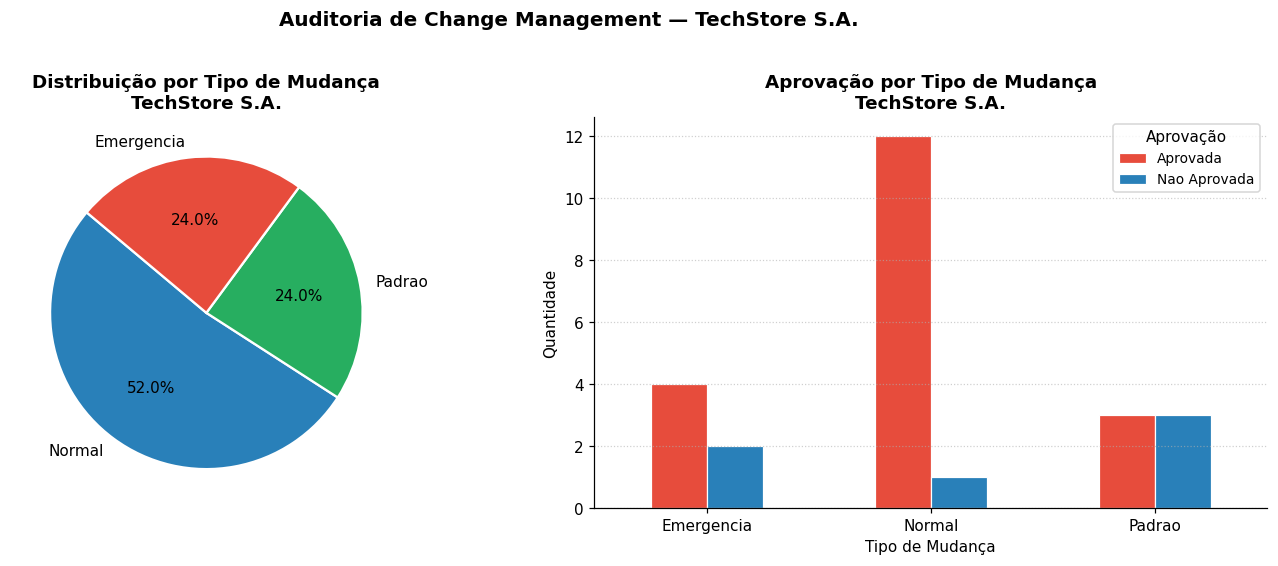

In [12]:
# ── Gráfico de Pizza — Tipos de Mudança ─────────────────────
PALETA = ["#2980b9", "#27ae60", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pizza: distribuição de tipos
axes[0].pie(
    contagem_tipos,
    labels=contagem_tipos.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=PALETA,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
    textprops={"fontsize": 10},
)
axes[0].set_title("Distribuição por Tipo de Mudança\nTechStore S.A.",
                  fontsize=12, fontweight="bold")

# Barras: aprovadas vs não aprovadas por tipo
aprovacao_tipo = df_mudancas.groupby(["tipo", "aprovacao"]).size().unstack(fill_value=0)
aprovacao_tipo.plot(
    kind="bar", ax=axes[1],
    color=["#e74c3c", "#2980b9"],
    edgecolor="white", linewidth=0.8
)
axes[1].set_title("Aprovação por Tipo de Mudança\nTechStore S.A.",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Tipo de Mudança", fontsize=10)
axes[1].set_ylabel("Quantidade", fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.grid(True, linestyle=":", alpha=0.6, zorder=0)
axes[1].legend(title="Aprovação", fontsize=9)

plt.suptitle("Auditoria de Change Management — TechStore S.A.",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## 🎫 Atividade 3 — Gerenciamento de Incidentes com Priorização por Fila

### Fundamentação Teórica

O **Gerenciamento de Incidentes** visa restaurar a operação normal o mais rápido possível.
O atendimento é organizado em **filas de suporte**:

| Fila | Função |
|------|--------|
| **N1** | Service Desk — triagem e incidentes simples |
| **N2** | Suporte especializado — incidentes complexos |

**Metas de SLA para incidentes de prioridade Alta:**
- ⏱️ Tempo máximo de espera em **N1**: 15 minutos (0,25 h)
- ⏱️ Tempo máximo de resolução total: 2 horas

**Cenário:** Log fictício de 20 incidentes com dados de tempo de espera e resolução.


In [13]:
# ============================================================
# ATIVIDADE 3 — GERENCIAMENTO DE INCIDENTES E FILAS (ITIL)
# ============================================================

random.seed(123)

N_INCIDENTES: int = 20

# Metas de SLA — TechStore S.A. (incidentes de prioridade Alta)
META_ESPERA_N1_HORAS: float    = 0.25   # 15 minutos
META_RESOLUCAO_HORAS: float    = 2.0    # 2 horas


def gerar_log_incidentes(n: int) -> pd.DataFrame:
    """Gera um DataFrame fictício de incidentes de suporte com filas.

    :param n: Quantidade de tickets a gerar.
    :return: DataFrame com ticket_id, prioridade, fila_inicial,
             tempo_espera_horas e tempo_resolucao_total_horas.
    """
    return pd.DataFrame({
        "ticket_id": range(2001, 2001 + n),
        "prioridade": [
            random.choice(["Alta", "Media", "Baixa"]) for _ in range(n)
        ],
        "fila_inicial": [
            random.choice(["N1", "N2"]) for _ in range(n)
        ],
        "tempo_espera_horas": [
            round(random.uniform(0.0, 0.8), 2) for _ in range(n)
        ],
        "tempo_resolucao_total_horas": [
            round(random.uniform(0.5, 5.0), 2) for _ in range(n)
        ],
    })


def violacoes_espera_n1(df_alta: pd.DataFrame, meta: float) -> pd.DataFrame:
    """Retorna incidentes de alta prioridade que violaram o SLA de espera em N1.

    :param df_alta: DataFrame filtrado apenas com incidentes de prioridade Alta.
    :param meta: Tempo máximo de espera em horas para a fila N1.
    :return: DataFrame com os tickets violadores.
    """
    return df_alta[
        (df_alta["fila_inicial"] == "N1") &
        (df_alta["tempo_espera_horas"] > meta)
    ].copy()


def violacoes_resolucao(df_alta: pd.DataFrame, meta: float) -> pd.DataFrame:
    """Retorna incidentes de alta prioridade que violaram o SLA de resolução total.

    :param df_alta: DataFrame filtrado apenas com incidentes de prioridade Alta.
    :param meta: Tempo máximo de resolução total em horas.
    :return: DataFrame com os tickets violadores.
    """
    return df_alta[df_alta["tempo_resolucao_total_horas"] > meta].copy()


# ── Geração e análise ─────────────────────────────────────────
df_incidentes = gerar_log_incidentes(N_INCIDENTES)
incidentes_alta = df_incidentes[df_incidentes["prioridade"] == "Alta"].copy()

viol_espera  = violacoes_espera_n1(incidentes_alta, META_ESPERA_N1_HORAS)
viol_resoluc = violacoes_resolucao(incidentes_alta, META_RESOLUCAO_HORAS)

# ── Relatório de Governança ──────────────────────────────────
LINHA = "=" * 66

print(f"{'LOG DE INCIDENTES POR FILA — TECHSTORE S.A.':^66}")
print(LINHA)
print(df_incidentes.to_string(index=False))

print(f"\n{LINHA}")
print("  RELATÓRIO DE GOVERNANÇA — GERENCIAMENTO DE INCIDENTES")
print("  (Foco: Prioridade Alta)")
print(LINHA)

# A) Espera em N1
print(f"\n  A) Violações de TEMPO DE ESPERA em N1")
print(f"     Critério: espera > {META_ESPERA_N1_HORAS} h (15 min)")
print(f"     Total de incidentes Alta em N1 : {len(incidentes_alta[incidentes_alta['fila_inicial']=='N1'])}")
if viol_espera.empty:
    print("     ✅ Nenhuma violação de tempo de espera em N1.")
else:
    print(viol_espera.to_string(index=False))
    print(f"\n     ❌ Total de violações de espera N1 : {len(viol_espera)}")

# B) Resolução total
print(f"\n  B) Violações de TEMPO TOTAL DE RESOLUÇÃO")
print(f"     Critério: resolução total > {META_RESOLUCAO_HORAS} h")
if viol_resoluc.empty:
    print("     ✅ Nenhuma violação de tempo de resolução.")
else:
    print(viol_resoluc.to_string(index=False))
    print(f"\n     ❌ Total de violações de resolução : {len(viol_resoluc)}")

# C) Estatísticas gerais
print(f"\n{LINHA}")
print("  ESTATÍSTICAS — Incidentes de Prioridade Alta")
print(LINHA)
print(incidentes_alta[["tempo_espera_horas", "tempo_resolucao_total_horas"]].describe().round(3).to_string())


           LOG DE INCIDENTES POR FILA — TECHSTORE S.A.            
 ticket_id prioridade fila_inicial  tempo_espera_horas  tempo_resolucao_total_horas
      2001       Alta           N1                0.67                         3.89
      2002      Media           N1                0.62                         1.32
      2003       Alta           N2                0.27                         4.19
      2004      Media           N1                0.64                         4.61
      2005      Media           N2                0.17                         3.46
      2006       Alta           N1                0.49                         1.27
      2007       Alta           N1                0.42                         2.02
      2008      Media           N2                0.65                         2.26
      2009      Baixa           N2                0.25                         0.83
      2010      Baixa           N1                0.32                         2.56
      201

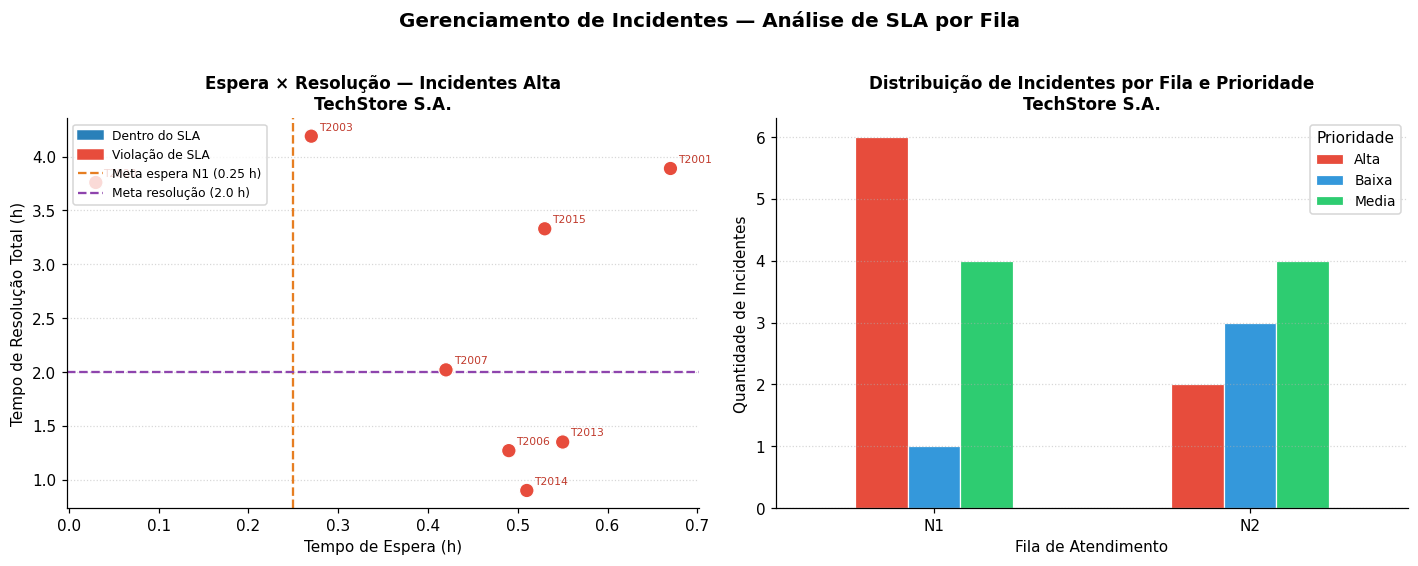

In [14]:
# ── Gráficos — Atividade 3 ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Gráfico 1: Scatter Espera × Resolução (Alta prioridade) ──
cores_scatter = [
    "#e74c3c"
    if (row["fila_inicial"] == "N1" and row["tempo_espera_horas"] > META_ESPERA_N1_HORAS)
    or row["tempo_resolucao_total_horas"] > META_RESOLUCAO_HORAS
    else "#2980b9"
    for _, row in incidentes_alta.iterrows()
]

axes[0].scatter(
    incidentes_alta["tempo_espera_horas"],
    incidentes_alta["tempo_resolucao_total_horas"],
    c=cores_scatter, s=90, edgecolors="white", linewidth=0.8, zorder=3
)
axes[0].axvline(x=META_ESPERA_N1_HORAS, color="#e67e22", linestyle="--",
                linewidth=1.5, label=f"Meta espera N1 ({META_ESPERA_N1_HORAS} h)")
axes[0].axhline(y=META_RESOLUCAO_HORAS, color="#8e44ad", linestyle="--",
                linewidth=1.5, label=f"Meta resolução ({META_RESOLUCAO_HORAS} h)")

# Anotação dos tickets violadores
for _, row in incidentes_alta.iterrows():
    if (row["fila_inicial"] == "N1" and row["tempo_espera_horas"] > META_ESPERA_N1_HORAS)        or row["tempo_resolucao_total_horas"] > META_RESOLUCAO_HORAS:
        axes[0].annotate(
            f"T{row['ticket_id']}",
            (row["tempo_espera_horas"], row["tempo_resolucao_total_horas"]),
            textcoords="offset points", xytext=(5, 4), fontsize=7, color="#c0392b"
        )

patch_ok  = mpatches.Patch(color="#2980b9", label="Dentro do SLA")
patch_vio = mpatches.Patch(color="#e74c3c", label="Violação de SLA")
axes[0].legend(handles=[patch_ok, patch_vio,
    plt.Line2D([0],[0], color="#e67e22", linestyle="--", linewidth=1.5,
               label=f"Meta espera N1 ({META_ESPERA_N1_HORAS} h)"),
    plt.Line2D([0],[0], color="#8e44ad", linestyle="--", linewidth=1.5,
               label=f"Meta resolução ({META_RESOLUCAO_HORAS} h)")],
    fontsize=8, loc="upper left")

axes[0].set_title("Espera × Resolução — Incidentes Alta\nTechStore S.A.",
                  fontsize=11, fontweight="bold")
axes[0].set_xlabel("Tempo de Espera (h)", fontsize=10)
axes[0].set_ylabel("Tempo de Resolução Total (h)", fontsize=10)
axes[0].yaxis.grid(True, linestyle=":", alpha=0.5)

# ── Gráfico 2: Distribuição de prioridades por fila ───────────
prioridade_fila = df_incidentes.groupby(["fila_inicial", "prioridade"]).size().unstack(fill_value=0)
prioridade_fila.plot(
    kind="bar", ax=axes[1],
    color=["#e74c3c", "#3498db", "#2ecc71"],
    edgecolor="white", linewidth=0.8
)
axes[1].set_title("Distribuição de Incidentes por Fila e Prioridade\nTechStore S.A.",
                  fontsize=11, fontweight="bold")
axes[1].set_xlabel("Fila de Atendimento", fontsize=10)
axes[1].set_ylabel("Quantidade de Incidentes", fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].yaxis.grid(True, linestyle=":", alpha=0.5, zorder=0)
axes[1].legend(title="Prioridade", fontsize=9)

plt.suptitle("Gerenciamento de Incidentes — Análise de SLA por Fila",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


---
## Conclusão

Este laboratório aplicou os três principais processos do **ITIL** usando Python e dados fictícios da TechStore S.A.:

| Atividade | Processo | O que foi feito |
|-----------|----------|-----------------|
| 1 | Gerenciamento de Disponibilidade | Calculamos o percentual de disponibilidade de 4 serviços e identificamos violações da meta de 99,5% do SLA |
| 2 | Gerenciamento de Mudanças | Auditamos 25 RFCs para detectar mudanças implementadas sem aprovação (não conformidades de governança) |
| 3 | Gerenciamento de Incidentes | Avaliamos o tempo de espera e de resolução em filas N1/N2 para incidentes de alta prioridade |

### Conceitos ITIL reforçados:
- **SLA** como ferramenta de alinhamento entre TI e negócio
- **Violação de disponibilidade** como gatilho de auditoria
- **RFC** e a importância de aprovação prévia para toda mudança
- **Priorização por fila** como estratégia de gerenciamento de incidentes
